### CLUSTERING


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../DATASET/dataset_expandido.csv")

In [3]:
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51,
    "Sem dado": np.nan
})

df["YearsCodePro"] = pd.to_numeric(
    df["YearsCodePro"],
    errors="coerce"
)

### Clustering 1 – Perfis Salariais.

In [4]:
features = [
    "YearsCodePro",
    "WorkExp",
    "Age_Code",
    "ConvertedCompYearly"
]

data = df[features].dropna()

print(data.shape)

(130452, 4)


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

In [6]:
inertia = []

k_values = range(1, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

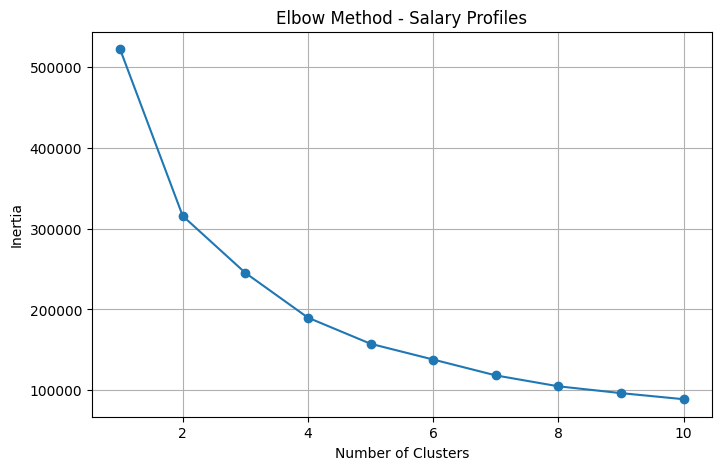

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method - Salary Profiles")

plt.grid()

plt.show()

In [8]:
silhouette_scores = []

k_range = range(2,11)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

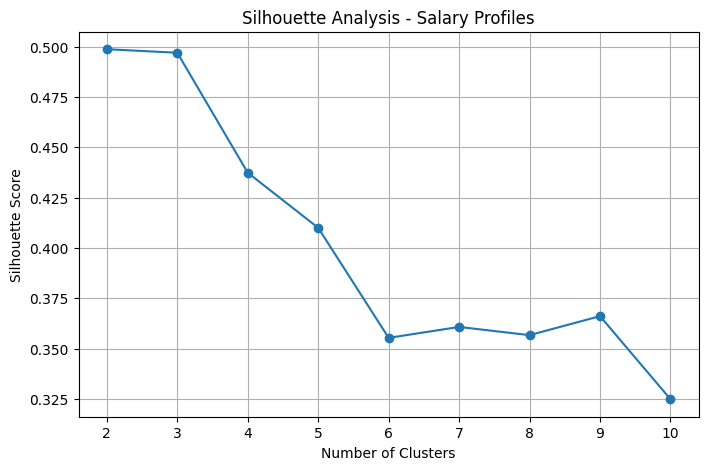

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis - Salary Profiles")

plt.grid()

plt.show()

In [16]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data["Cluster"] = clusters

In [17]:
print(
    data["Cluster"].value_counts()
)

Cluster
1    93915
0    36529
2        8
Name: count, dtype: int64


In [18]:
cluster_profiles = data.groupby(
    "Cluster"
).mean()

cluster_profiles.round(2)

,YearsCodePro,WorkExp,Age_Code,ConvertedCompYearly
Cluster,,,,
0,21.84,17.39,4.73,92552.72
1,5.71,7.64,2.92,66279.47
2,9.00,11.00,2.88,10446721.88


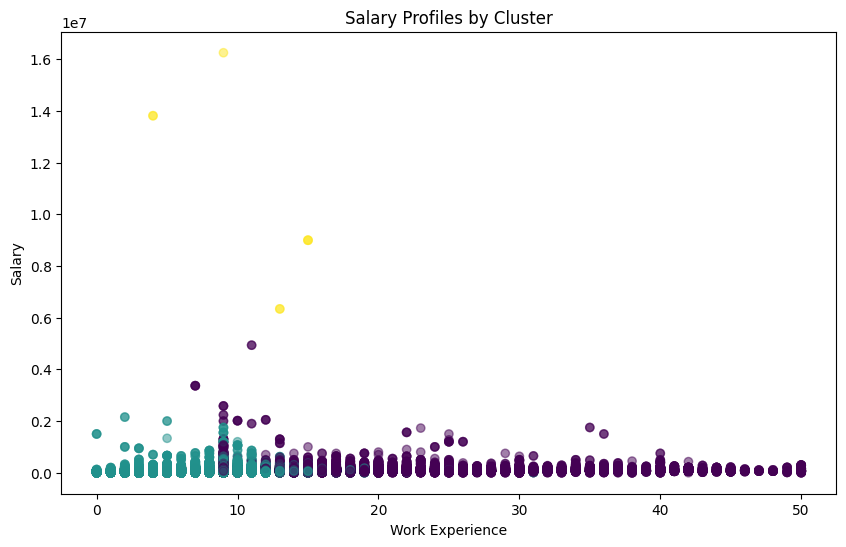

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    data["WorkExp"],
    data["ConvertedCompYearly"],
    c=data["Cluster"],
    alpha=0.5
)

plt.xlabel("Work Experience")
plt.ylabel("Salary")

plt.title("Salary Profiles by Cluster")

plt.show()

In [20]:
sample = data.sample(
    n=1000,
    random_state=42
)

In [21]:
sample_scaled = StandardScaler().fit_transform(
    sample[[
        "YearsCodePro",
        "WorkExp",
        "Age_Code",
        "ConvertedCompYearly"
    ]]
)

In [22]:
linked = linkage(
    sample_scaled,
    method="ward"
)

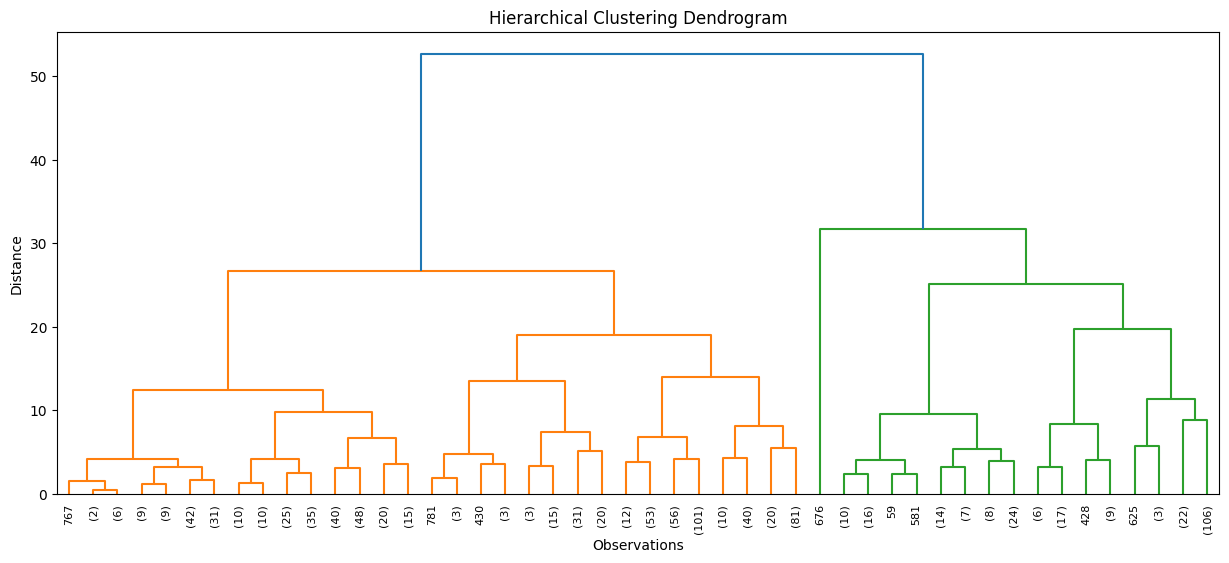

In [23]:
plt.figure(figsize=(15,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

# CLUSTERING 2 - Perfis de Emprego

In [24]:
features_emp = [
    "YearsCodePro",
    "WorkExp",
    "Age_Code",
    "JobSat"
]

data_emp = df[features_emp].copy()

In [25]:
data_emp["YearsCodePro"] = data_emp["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 51,
    "Sem dado": np.nan
})

data_emp["YearsCodePro"] = pd.to_numeric(
    data_emp["YearsCodePro"],
    errors="coerce"
)

data_emp = data_emp.dropna()

print(data_emp.shape)

(130452, 4)


In [26]:
scaler_emp = StandardScaler()

X_emp = scaler_emp.fit_transform(
    data_emp
)

In [27]:
inertia_emp = []

k_values_emp = range(1,11)

for k in k_values_emp:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_emp)

    inertia_emp.append(
        kmeans.inertia_
    )

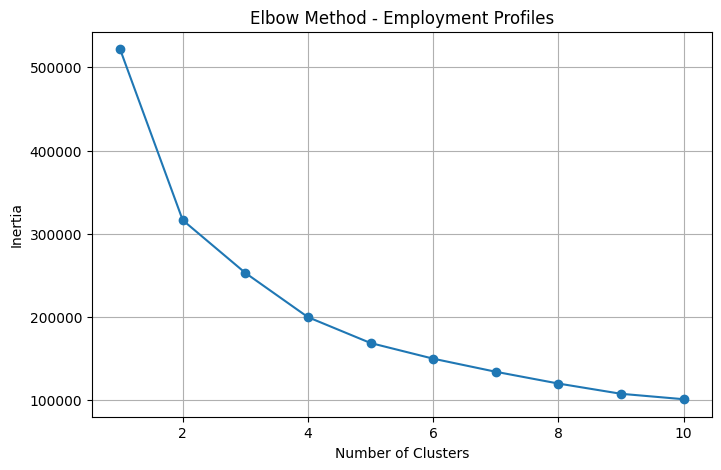

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values_emp,
    inertia_emp,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method - Employment Profiles"
)

plt.grid()

plt.show()

In [29]:
silhouette_scores_emp = []

k_range_emp = range(2,11)

for k in k_range_emp:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_emp
    )

    score = silhouette_score(
        X_emp,
        labels
    )

    silhouette_scores_emp.append(
        score
    )

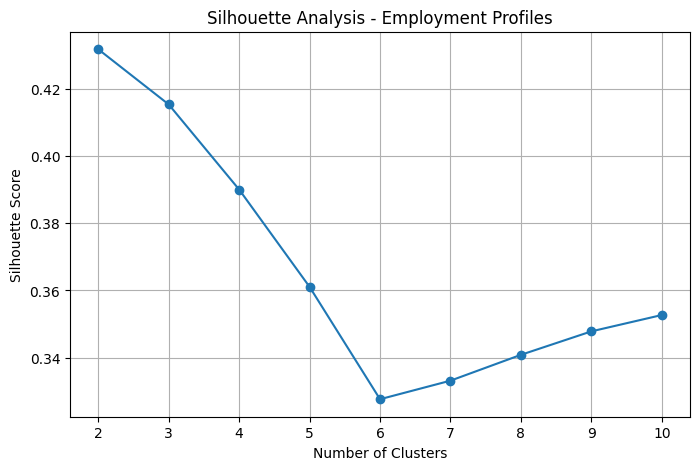

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    k_range_emp,
    silhouette_scores_emp,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Analysis - Employment Profiles"
)

plt.grid()

plt.show()

In [32]:
best_k_emp = 3

kmeans_emp = KMeans(
    n_clusters=best_k_emp,
    random_state=42,
    n_init=10
)

clusters_emp = kmeans_emp.fit_predict(
    X_emp
)

In [33]:
print("Linhas data:", len(data))
print("Clusters:", len(clusters_emp))

Linhas data: 130452
Clusters: 130452


In [34]:
data["Cluster_Emp"] = clusters_emp

In [35]:
print(
    data["Cluster_Emp"].value_counts()
)

Cluster_Emp
2    86461
1    32098
0    11893
Name: count, dtype: int64


In [36]:
cluster_profiles_emp = data.groupby(
    "Cluster_Emp"
).mean()

cluster_profiles_emp.round(2)

,YearsCodePro,WorkExp,Age_Code,ConvertedCompYearly,Cluster
Cluster_Emp,,,,,
0,7.08,8.02,3.13,68500.95,0.84
1,22.89,17.80,4.82,88783.29,0.00
2,5.96,7.93,2.95,69680.21,0.97


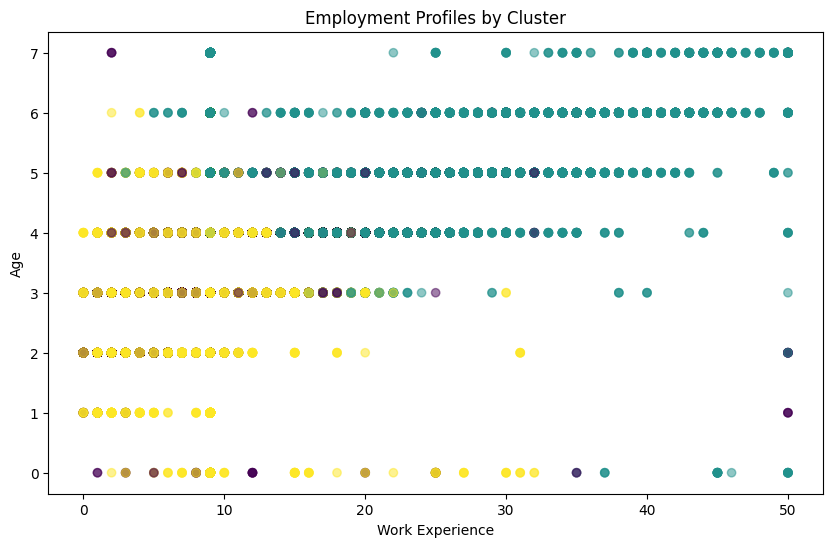

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    data["WorkExp"],
    data["Age_Code"],
    c=data["Cluster_Emp"],
    alpha=0.5
)

plt.xlabel("Work Experience")
plt.ylabel("Age")

plt.title(
    "Employment Profiles by Cluster"
)

plt.show()

In [38]:
sample_emp = data.sample(
    n=1000,
    random_state=42
)

In [39]:
sample_emp_scaled = StandardScaler().fit_transform(
    sample_emp[
        [
            "YearsCodePro",
            "WorkExp",
            "Age_Code"
        ]
    ]
)

In [40]:
linked_emp = linkage(
    sample_emp_scaled,
    method="ward"
)

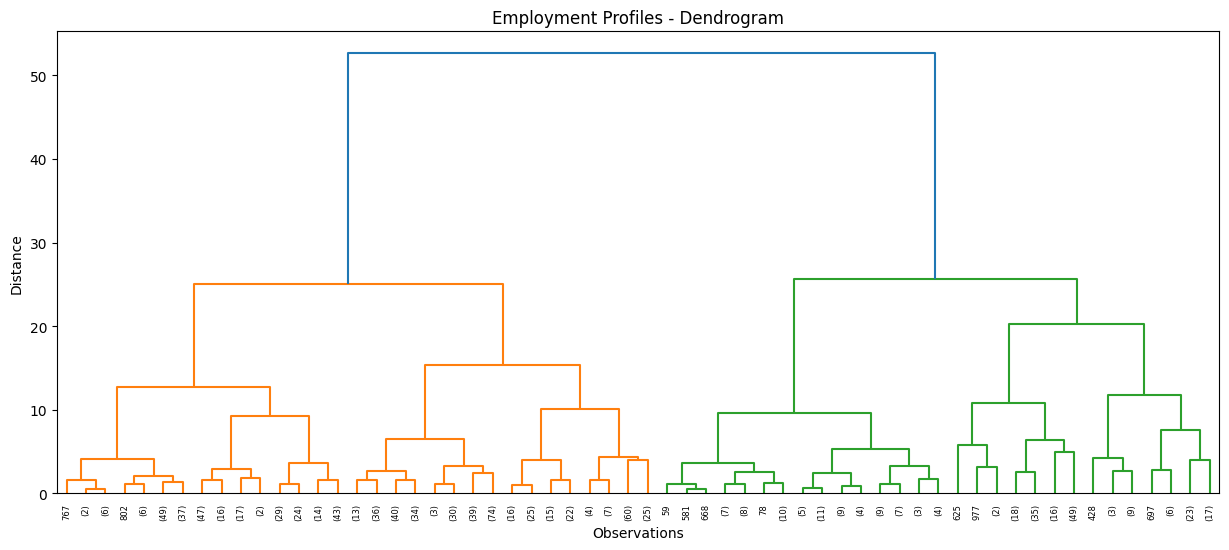

In [41]:
plt.figure(figsize=(15,6))

dendrogram(
    linked_emp,
    truncate_mode="level",
    p=5
)

plt.title(
    "Employment Profiles - Dendrogram"
)

plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()